# LambdaRank
It is a crucial algorithm in `Learning to Rank` (LTR), primarily used for optimizing ranking models. Unlike traditional `pointwise` or `pairwise` loss functions, LambdaRank doesn't directly optimize a loss based on individual document relevance or pairwise preferences. Instead, it estimates the `gradients (lambdas)` of a ranking metric (like NDCG or MRR) with respect to the scores assigned to documents. These `'lambdas'` effectively represent the **importance** of swapping a particular pair of documents. This allows the model to prioritize correcting ranking errors that have a larger impact on the overall ranking metric.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

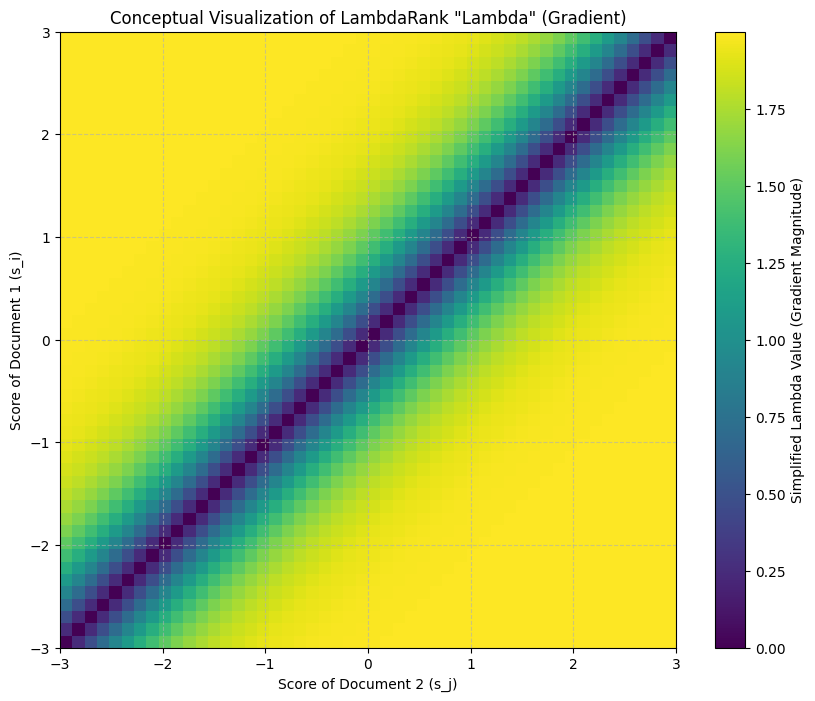

Interpretation of the visualization:
- The 'lambda' represents the gradient of a ranking metric (like NDCG) with respect to the document scores.
Higher lambda values (brighter colors) indicate that a small change in scores for those documents 
would lead to a larger change in the ranking metric, suggesting a more impactful ranking error.
- In this simplified example, if Document 1 (s_i) has a much higher true relevance than Document 2 (s_j), 
the lambdas are high when their predicted scores are 'incorrectly' ordered (i.e., s_j is high while s_i is low, 
or vice versa if relevance difference was negative), indicating a strong signal to adjust scores.
- LambdaRank uses these 'lambdas' to update the model's parameters, aiming to optimize the overall ranking quality directly.


In [3]:
# Simplified example: Lambda (gradient) based on score difference and relevance
# In a real scenario, lambda depends on the specific ranking metric (e.g., NDCG)
# and the actual positions of documents.

def calculate_simplified_lambda(s_i, s_j, r_i, r_j):
    """
    A highly simplified conceptual lambda calculation.
    In reality, lambda is a complex gradient of a ranking metric.
    Here, we simulate its dependence on score difference and relevance difference.
    """
    sigma = 1.0 # A scaling factor, similar to a sigmoid slope
    # The lambda value is often related to the difference in scores and relevance
    # and the change in the ranking metric if documents were swapped.
    # This is a conceptual approximation for visualization.
    lambda_val = np.abs(np.tanh(sigma * (s_i - s_j))) * (r_i - r_j)
    return lambda_val

# Assume some hypothetical scores and relevance labels for two documents
scores_doc1 = np.linspace(-3, 3, 50) # Score for document i
relevance_doc1 = 3 # True relevance for document i (e.g., highly relevant)

scores_doc2 = np.linspace(-3, 3, 50) # Score for document j
relevance_doc2 = 1 # True relevance for document j (e.g., somewhat relevant)

# Create a meshgrid for visualization
S1, S2 = np.meshgrid(scores_doc1, scores_doc2)

# Calculate lambda values across the meshgrid
# We'll calculate the 'lambda' for swapping doc1 and doc2
# assuming doc1 should be ranked higher than doc2 (r_i > r_j)
lambda_matrix = calculate_simplified_lambda(S1, S2, relevance_doc1, relevance_doc2)

plt.figure(figsize=(10, 8))
plt.imshow(lambda_matrix, origin='lower', cmap='viridis', extent=[min(scores_doc2), max(scores_doc2), min(scores_doc1), max(scores_doc1)])
plt.colorbar(label='Simplified Lambda Value (Gradient Magnitude)')
plt.xlabel('Score of Document 2 (s_j)')
plt.ylabel('Score of Document 1 (s_i)')
plt.title('Conceptual Visualization of LambdaRank "Lambda" (Gradient)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Interpretation of the visualization:")
print("- The 'lambda' represents the gradient of a ranking metric (like NDCG) with respect to the document scores.")
print("""Higher lambda values (brighter colors) indicate that a small change in scores for those documents
would lead to a larger change in the ranking metric, suggesting a more impactful ranking error.""")
print("""- In this simplified example, if Document 1 (s_i) has a much higher true relevance than Document 2 (s_j),
the lambdas are high when their predicted scores are 'incorrectly' ordered (i.e., s_j is high while s_i is low,
or vice versa if relevance difference was negative), indicating a strong signal to adjust scores.""")
print("- LambdaRank uses these 'lambdas' to update the model's parameters, aiming to optimize the overall ranking quality directly.")